In [11]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sb
import os
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd
import numpy as np
from scipy.stats import shapiro
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer



In [12]:

df = pd.read_csv("/content/bdhs2022_final_analysis_dataset_new.csv")

In [13]:
df.head()

,age_months,sample_weight,cluster_id,hh_id,child_line,mother_edu,birth_order,mother_occ,birth_interval_months,children_ever_born,...,toilet_improved,delivery_place_3cat,has_tv_clean,has_electricity_clean,reads_newspaper_clean,small_at_birth,wants_more_children,wealth_index_clean,stunted,haz
0,32.0,156207.0,1.0,111.0,1.0,3.0,2.0,1.0,63.0,2.0,...,1.0,1.0,1.0,1.0,1.0,0.0,0.0,4,0.0,0.08
1,18.0,141953.0,2.0,3.0,1.0,2.0,2.0,0.0,56.0,2.0,...,0.0,2.0,1.0,1.0,0.0,0.0,0.0,4,0.0,-1.61
2,14.0,141953.0,2.0,23.0,1.0,3.0,1.0,0.0,NaN,1.0,...,1.0,2.0,1.0,1.0,0.0,1.0,1.0,5,0.0,-1.29
3,NaN,141953.0,2.0,34.0,1.0,3.0,3.0,0.0,46.0,3.0,...,1.0,2.0,1.0,1.0,0.0,0.0,1.0,4,1.0,-2.27
4,5.0,141953.0,2.0,146.0,1.0,2.0,2.0,0.0,24.0,2.0,...,1.0,2.0,1.0,1.0,1.0,1.0,1.0,5,0.0,-0.31


In [14]:
df.tail()

,age_months,sample_weight,cluster_id,hh_id,child_line,mother_edu,birth_order,mother_occ,birth_interval_months,children_ever_born,...,toilet_improved,delivery_place_3cat,has_tv_clean,has_electricity_clean,reads_newspaper_clean,small_at_birth,wants_more_children,wealth_index_clean,stunted,haz
2486,6.0,699635.0,675.0,31.0,1.0,1.0,4.0,0.0,77.0,4.0,...,1.0,1.0,0.0,1.0,0.0,0.0,0.0,2,0.0,-1.92
2487,23.0,699635.0,675.0,41.0,2.0,0.0,2.0,0.0,34.0,3.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2,1.0,-3.10
2488,2.0,699635.0,675.0,70.0,1.0,1.0,3.0,0.0,25.0,3.0,...,1.0,2.0,0.0,1.0,0.0,0.0,0.0,1,0.0,-0.47
2489,28.0,699635.0,675.0,70.0,2.0,1.0,2.0,0.0,41.0,3.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,0.0,-1.79
2490,12.0,699635.0,675.0,108.0,1.0,2.0,2.0,0.0,34.0,2.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,2,0.0,-1.00


In [15]:
df.shape

(2491, 27)

In [16]:
print(df.columns.tolist())

['age_months', 'sample_weight', 'cluster_id', 'hh_id', 'child_line', 'mother_edu', 'birth_order', 'mother_occ', 'birth_interval_months', 'children_ever_born', 'father_edu', 'division', 'mother_age', 'wt', 'mother_bmi', 'father_occ_clean', 'skilled_birth', 'toilet_improved', 'delivery_place_3cat', 'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean', 'small_at_birth', 'wants_more_children', 'wealth_index_clean', 'stunted', 'haz']


In [17]:
df.columns.tolist()

['age_months',
 'sample_weight',
 'cluster_id',
 'hh_id',
 'child_line',
 'mother_edu',
 'birth_order',
 'mother_occ',
 'birth_interval_months',
 'children_ever_born',
 'father_edu',
 'division',
 'mother_age',
 'wt',
 'mother_bmi',
 'father_occ_clean',
 'skilled_birth',
 'toilet_improved',
 'delivery_place_3cat',
 'has_tv_clean',
 'has_electricity_clean',
 'reads_newspaper_clean',
 'small_at_birth',
 'wants_more_children',
 'wealth_index_clean',
 'stunted',
 'haz']

# missing value check  
# heatmap

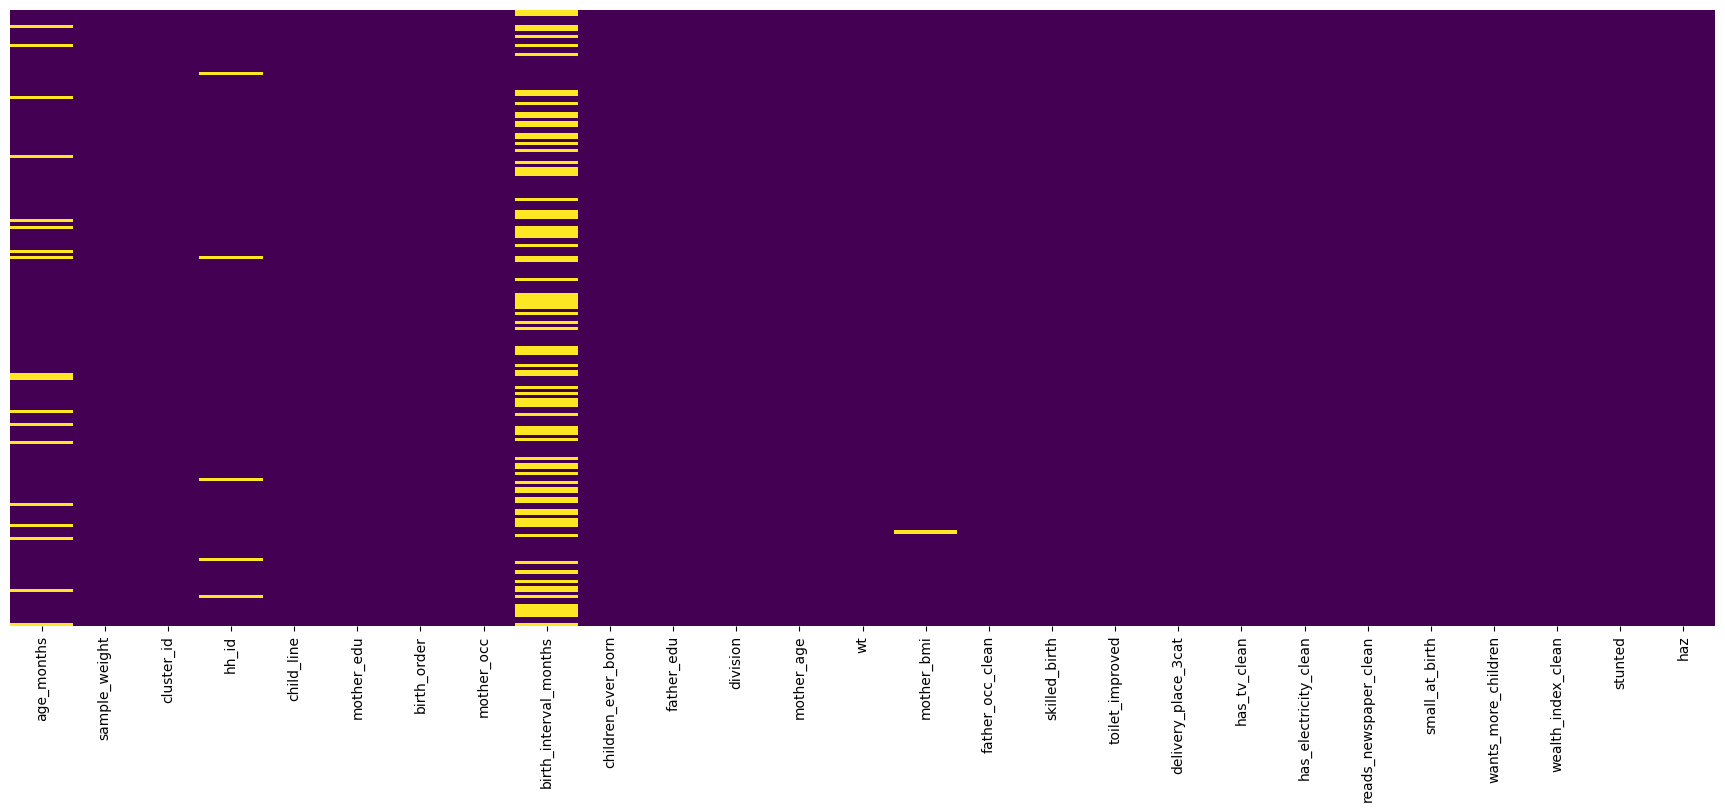

In [18]:
plt.figure(figsize=(22, 8))
sns.heatmap(
  df.sample(200).isnull(),  # sample rows
    yticklabels=False,
    cbar=False,
    cmap='viridis'
)
plt.show()


# Bar chart

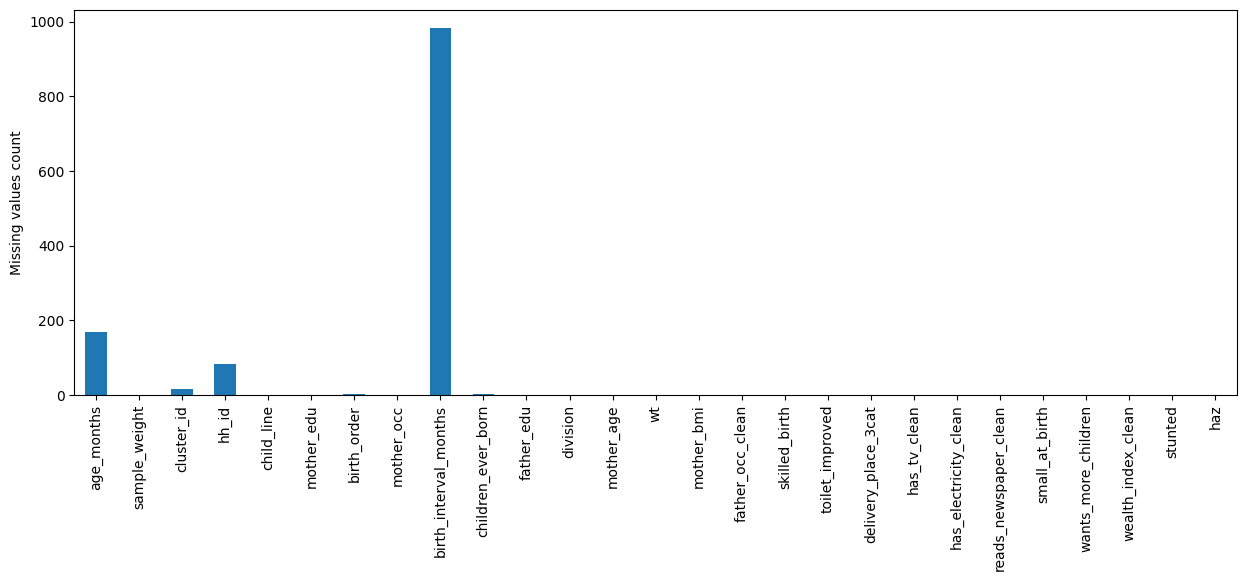

In [19]:
df.isnull().sum().plot(kind='bar', figsize=(15,5))
plt.ylabel("Missing values count")
plt.show() # bar chart


In [20]:
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)

                 Variable  Missing_Percent
8   birth_interval_months        39.462063
0              age_months         6.744279
3                   hh_id         3.291851
2              cluster_id         0.602168
9      children_ever_born         0.080289
6             birth_order         0.080289
14             mother_bmi         0.040145
5              mother_edu         0.000000
4              child_line         0.000000
7              mother_occ         0.000000
1           sample_weight         0.000000
10             father_edu         0.000000
11               division         0.000000
12             mother_age         0.000000
13                     wt         0.000000
15       father_occ_clean         0.000000
16          skilled_birth         0.000000
17        toilet_improved         0.000000
18    delivery_place_3cat         0.000000
19           has_tv_clean         0.000000
20  has_electricity_clean         0.000000
21  reads_newspaper_clean         0.000000
22         

In [21]:
df = df.drop(columns=['hh_id', 'cluster_id'])

In [22]:
df.shape

(2491, 25)

In [23]:
missing_percent = df.isnull().mean() * 100

In [24]:
threshold = 30


In [25]:
df = df.loc[:, missing_percent <= threshold]


In [26]:
cols_to_drop = missing_percent[missing_percent > 30].index
print(cols_to_drop)


Index(['birth_interval_months'], dtype='object')


In [27]:
df.shape

(2491, 24)

In [28]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols

Index(['age_months', 'sample_weight', 'child_line', 'mother_edu',
       'birth_order', 'mother_occ', 'children_ever_born', 'father_edu',
       'division', 'mother_age', 'wt', 'mother_bmi', 'father_occ_clean',
       'skilled_birth', 'toilet_improved', 'delivery_place_3cat',
       'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean',
       'small_at_birth', 'wants_more_children', 'wealth_index_clean',
       'stunted', 'haz'],
      dtype='object')

In [29]:
id_vars = ['cluster_id', 'hh_id', 'child_line']


In [30]:
numeric_vars = [
   'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]


In [31]:
all_df_cols = df.columns.tolist()

# Filter id_vars to only include columns that are still in df
current_id_vars = [col for col in id_vars if col in all_df_cols]

# Filter numeric_vars to only include columns that are still in df
current_numeric_vars = [col for col in numeric_vars if col in all_df_cols]

categorical_vars = list(
    set(all_df_cols) - set(current_id_vars) - set(current_numeric_vars)
)



In [32]:
print("ID variables:\n", id_vars)
print("\nNumeric variables:\n", numeric_vars)
print("\nCategorical variables:\n", categorical_vars)


ID variables:
 ['cluster_id', 'hh_id', 'child_line']

Numeric variables:
 ['age_months', 'children_ever_born', 'mother_age', 'birth_order', 'mother_bmi']

Categorical variables:
 ['wants_more_children', 'small_at_birth', 'has_electricity_clean', 'haz', 'reads_newspaper_clean', 'father_occ_clean', 'toilet_improved', 'mother_occ', 'wt', 'father_edu', 'skilled_birth', 'sample_weight', 'delivery_place_3cat', 'mother_edu', 'division', 'has_tv_clean', 'stunted', 'wealth_index_clean']


# Normality check

In [33]:


# Numeric (continuous) variables from our dataset
numeric_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

normality_results = []

for col in numeric_vars:
    data = df[col].dropna()

    # Skip very small samples
    if len(data) < 10:
        continue

    skewness = data.skew()

    # Shapiro test (sample if dataset is large)
    stat, p_value = shapiro(data.sample(500) if len(data) > 500 else data)

    normality_results.append({
        "Variable": col,
        "Skewness": round(skewness, 3),
        "Shapiro_p_value": round(p_value, 4),
        "Distribution": "Normal" if p_value > 0.05 else "Non-normal"
    })

# Create normality table
normality_table = pd.DataFrame(normality_results)

normality_table


,Variable,Skewness,Shapiro_p_value,Distribution
0,age_months,-0.062,0.0,Non-normal
1,children_ever_born,1.200,0.0,Non-normal
2,mother_age,0.543,0.0,Non-normal
3,birth_order,1.207,0.0,Non-normal
4,mother_bmi,0.687,0.0,Non-normal


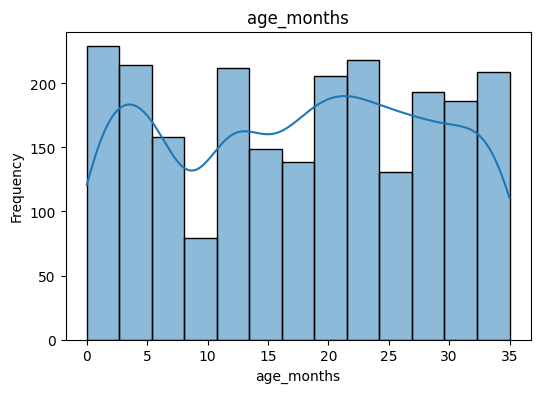

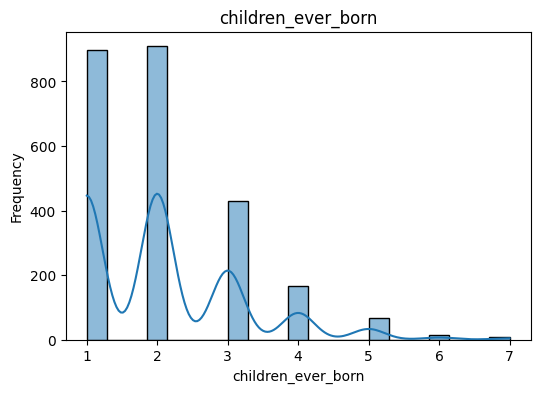

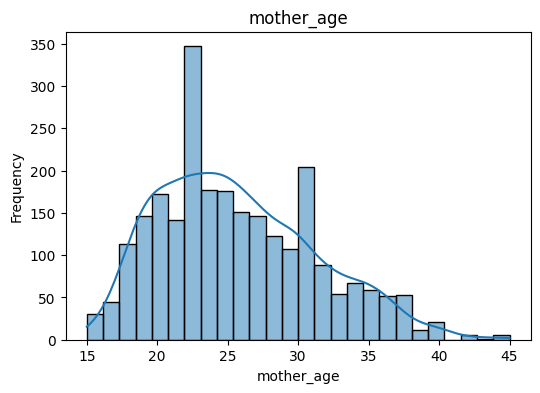

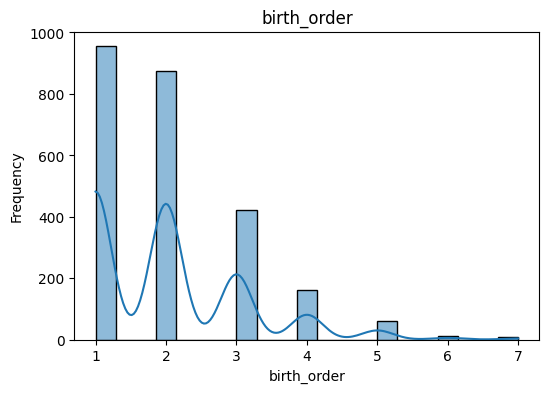

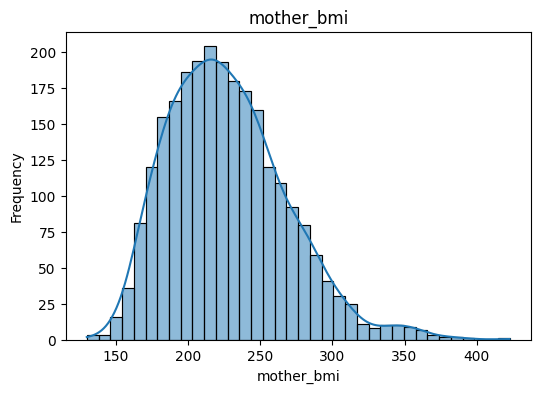

In [34]:


# List of numeric variables (non-normal)
numeric_cols = [
      'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
]

# Plot each variable individually
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)   # pass only one column at a time
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

# MICE PMM

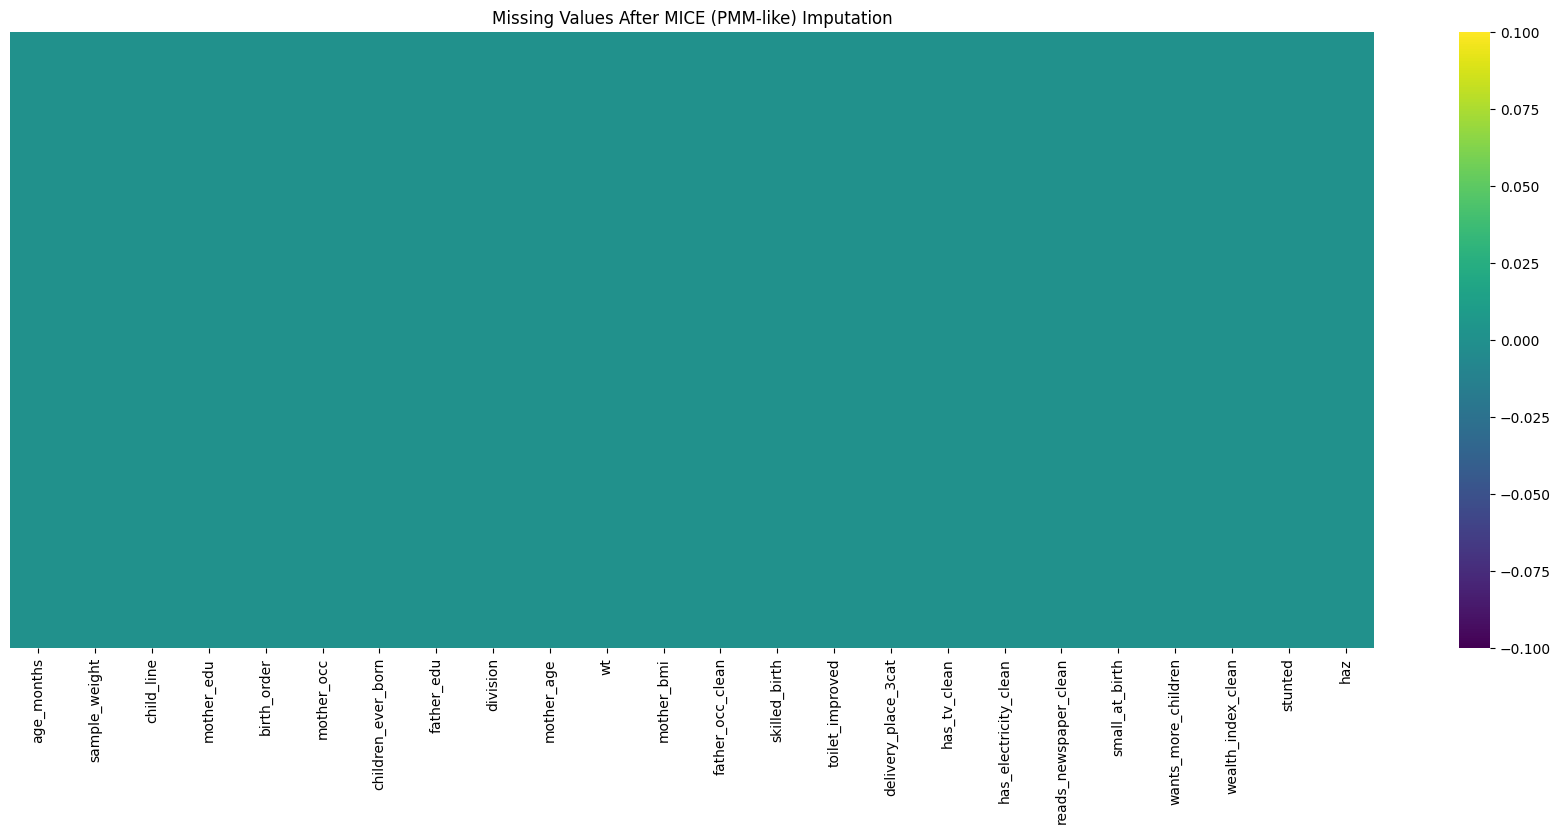

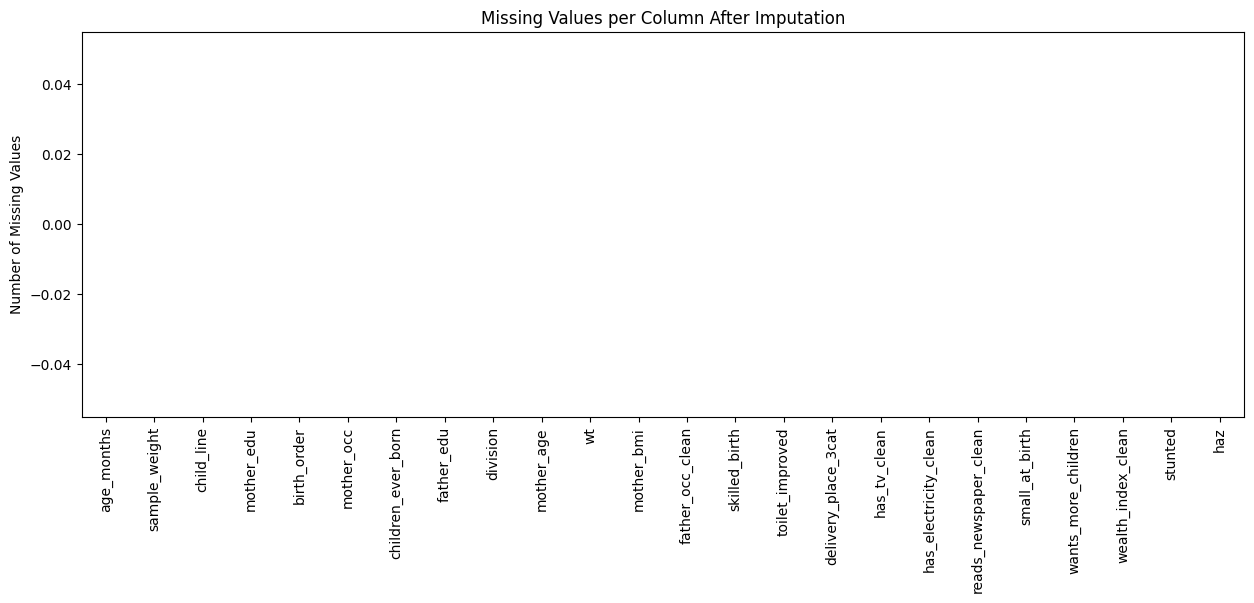

Total missing values after imputation: 0


In [35]:

# =============================
# Imports (Colab compatible)
# =============================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# =============================
# Load data (example)
# =============================
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])

# =============================
# Define NON-NORMAL variables
# =============================
non_normal_vars = [
    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',]

# =============================
# MICE / PMM-like Imputation
# =============================
mice_imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=10,
    random_state=42,
    sample_posterior=True
)

df[non_normal_vars] = mice_imputer.fit_transform(df[non_normal_vars])

# =============================
# Check missing values
# =============================
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='viridis')
plt.title("Missing Values After MICE (PMM-like) Imputation")
plt.show()

df.isnull().sum().sort_values(ascending=False).plot(
    kind='bar', figsize=(15, 5)
)
plt.ylabel("Number of Missing Values")
plt.title("Missing Values per Column After Imputation")
plt.show()

print("Total missing values after imputation:", df.isnull().sum().sum())

In [36]:
import pandas as pd

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_percent.index,
    'Missing_Percent': missing_percent.values
}).sort_values(by='Missing_Percent', ascending=False)

print(missing_df)



                 Variable  Missing_Percent
0              age_months              0.0
1           sample_weight              0.0
2              child_line              0.0
3              mother_edu              0.0
4             birth_order              0.0
5              mother_occ              0.0
6      children_ever_born              0.0
7              father_edu              0.0
8                division              0.0
9              mother_age              0.0
10                     wt              0.0
11             mother_bmi              0.0
12       father_occ_clean              0.0
13          skilled_birth              0.0
14        toilet_improved              0.0
15    delivery_place_3cat              0.0
16           has_tv_clean              0.0
17  has_electricity_clean              0.0
18  reads_newspaper_clean              0.0
19         small_at_birth              0.0
20    wants_more_children              0.0
21     wealth_index_clean              0.0
22         

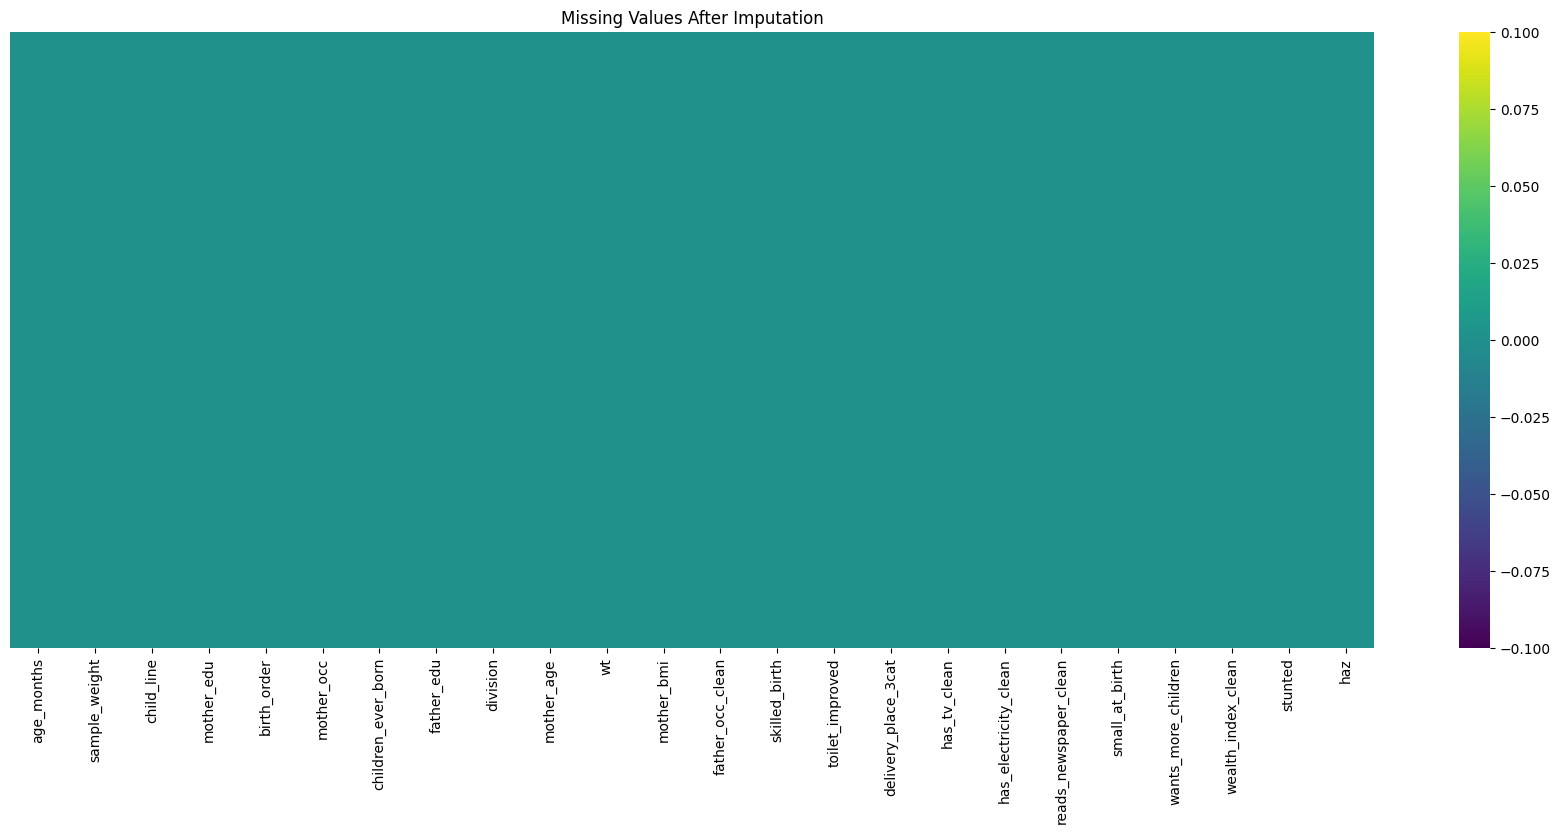

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(22,8))  # make it wide enough for all columns
sns.heatmap(df.isnull(),
            yticklabels=False,
            cbar=True,
            cmap='viridis')

plt.title("Missing Values After Imputation")
plt.show()


aftre missing value handled we have 24 variable

In [38]:
df.shape

(2491, 24)

In [39]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age_months,2491.0,1.758312e+01,10.654874,-5.135347,7.000000,18.000000,2.600000e+01,4.583307e+01
sample_weight,2491.0,1.017775e+06,512971.185567,91325.000000,670684.000000,956806.000000,1.333414e+06,3.891736e+06
child_line,2491.0,1.045363e+00,0.211965,1.000000,1.000000,1.000000,1.000000e+00,3.000000e+00
mother_edu,2491.0,1.867122e+00,0.785158,0.000000,1.000000,2.000000,2.000000e+00,3.000000e+00
birth_order,2491.0,2.017559e+00,1.078969,1.000000,1.000000,2.000000,3.000000e+00,7.000000e+00
mother_occ,2491.0,2.079486e-01,0.405921,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00
children_ever_born,2491.0,2.063017e+00,1.094907,1.000000,1.000000,2.000000,3.000000e+00,7.000000e+00
father_edu,2491.0,1.615415e+00,0.970564,0.000000,1.000000,2.000000,2.000000e+00,3.000000e+00
division,2491.0,3.586511e+00,1.925741,1.000000,2.000000,3.000000,5.000000e+00,7.000000e+00
mother_age,2491.0,2.567041e+01,5.577652,15.000000,21.000000,25.000000,2.900000e+01,4.500000e+01


In [40]:
# Ensure lists match existing columns
numeric_vars = [col for col in numeric_vars if col in df.columns]
categorical_vars = [col for col in categorical_vars if col in df.columns]

# Convert numeric-coded categorical variables to 'category' type
for col in categorical_vars:
    df[col] = df[col].astype('category')

# Now describe
print(df[numeric_vars].describe())
print(df[categorical_vars].describe())


        age_months  children_ever_born   mother_age  birth_order   mother_bmi
count  2491.000000         2491.000000  2491.000000  2491.000000  2491.000000
mean     17.583119            2.063017    25.670413     2.017559   227.291901
std      10.654874            1.094907     5.577652     1.078969    41.025877
min      -5.135347            1.000000    15.000000     1.000000   130.000000
25%       7.000000            1.000000    21.000000     1.000000   196.500000
50%      18.000000            2.000000    25.000000     2.000000   223.000000
75%      26.000000            3.000000    29.000000     3.000000   251.850000
max      45.833074            7.000000    45.000000     7.000000   422.700000
        wants_more_children  small_at_birth  has_electricity_clean      haz  \
count                2491.0          2491.0                 2491.0  2491.00   
unique                  2.0             2.0                    2.0   563.00   
top                     0.0             0.0                  

### **Univariate Analysis (1st numerical 2nd categorical)**
# histplot and countplot to understand  the distribution




### Correlation heatmap for Numerical variable.

#boxplot to identify the outlier

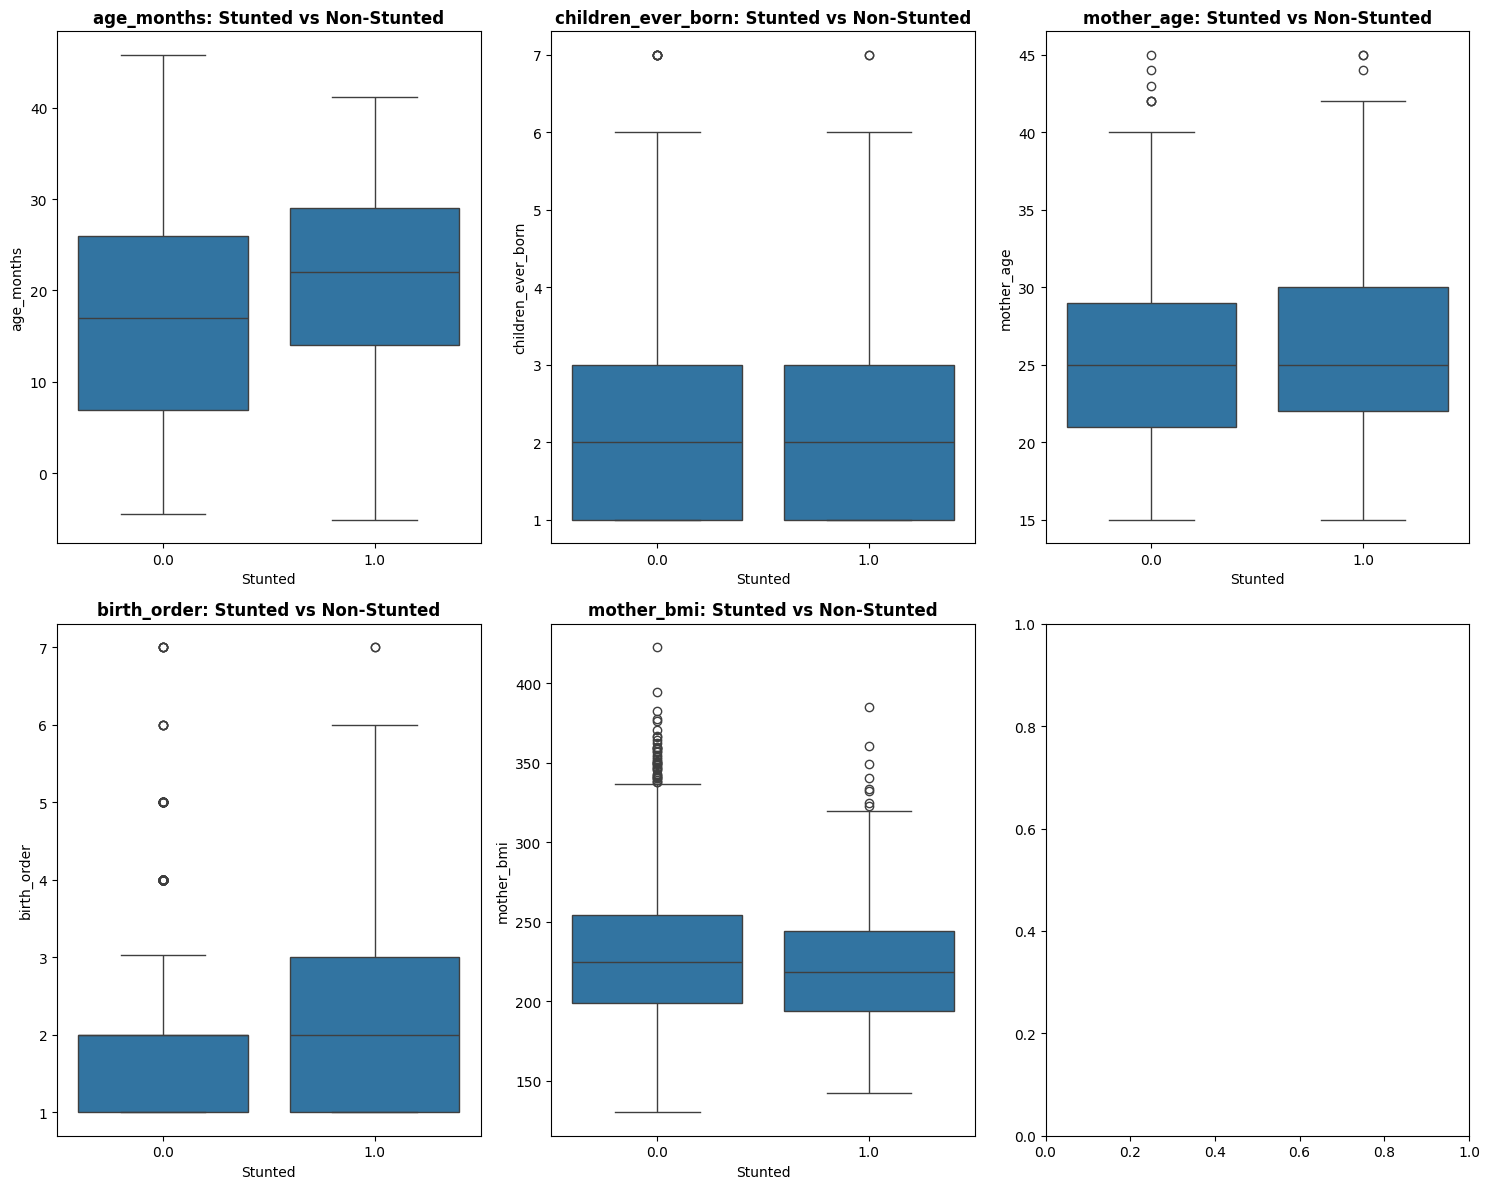

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1A. Stunting vs Key Continuous Variables
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.ravel()

key_vars = [    'age_months',
    'children_ever_born',
    'mother_age',
    'birth_order',
    'mother_bmi',
   ]

for i, var in enumerate(key_vars):
    sns.boxplot(data=df, x='stunted', y=var, ax=axes[i])
    axes[i].set_title(f'{var}: Stunted vs Non-Stunted', fontweight='bold')
    axes[i].set_xlabel('Stunted')

plt.tight_layout()
plt.show()

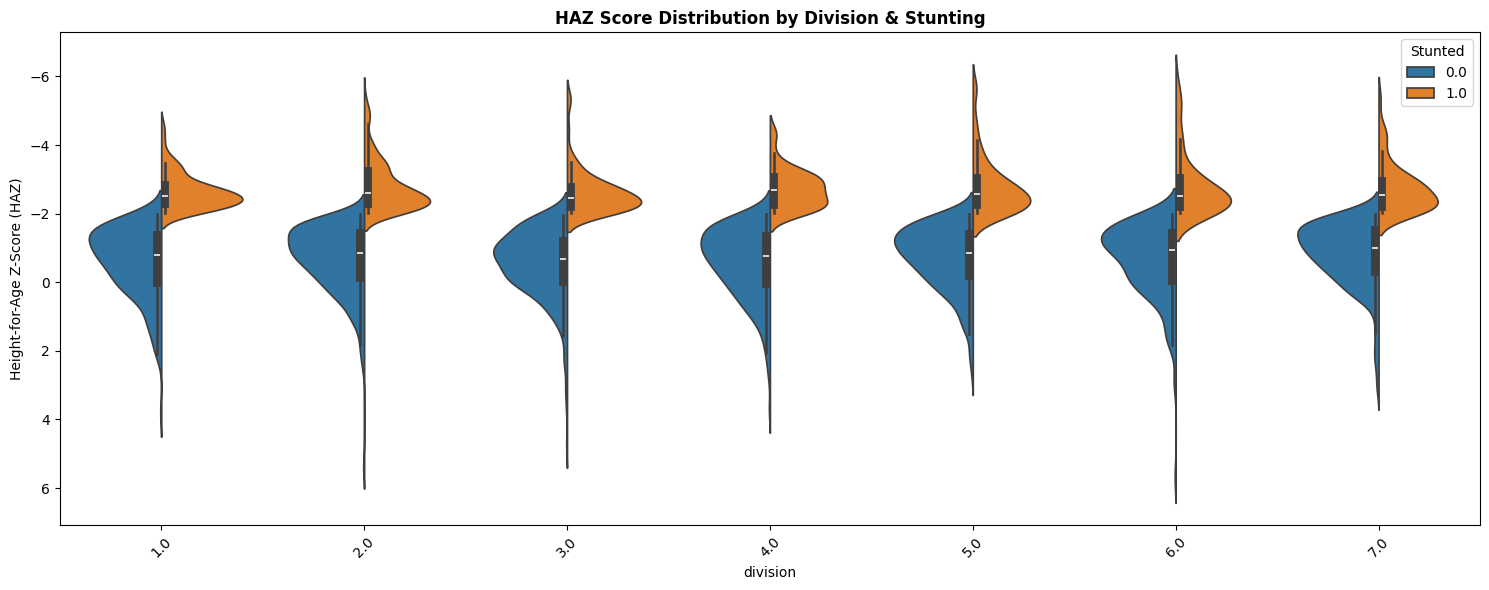

In [45]:
plt.figure(figsize=(15, 6))
sns.violinplot(data=df, x='division', y='haz', hue='stunted', split=True)
plt.title('HAZ Score Distribution by Division & Stunting', fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Height-for-Age Z-Score (HAZ)')
plt.legend(title='Stunted')
plt.tight_layout()
plt.show()

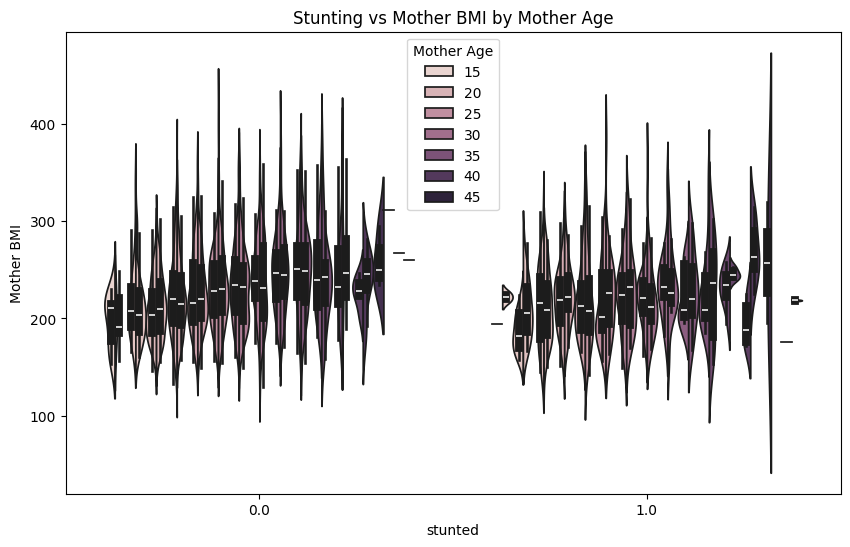

In [46]:
# 1B. Stunting vs Mother BMI
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='stunted', y='mother_bmi', hue='mother_age', split=True)
plt.title('Stunting vs Mother BMI by Mother Age')
plt.ylabel('Mother BMI')
plt.legend(title='Mother Age')
plt.show()

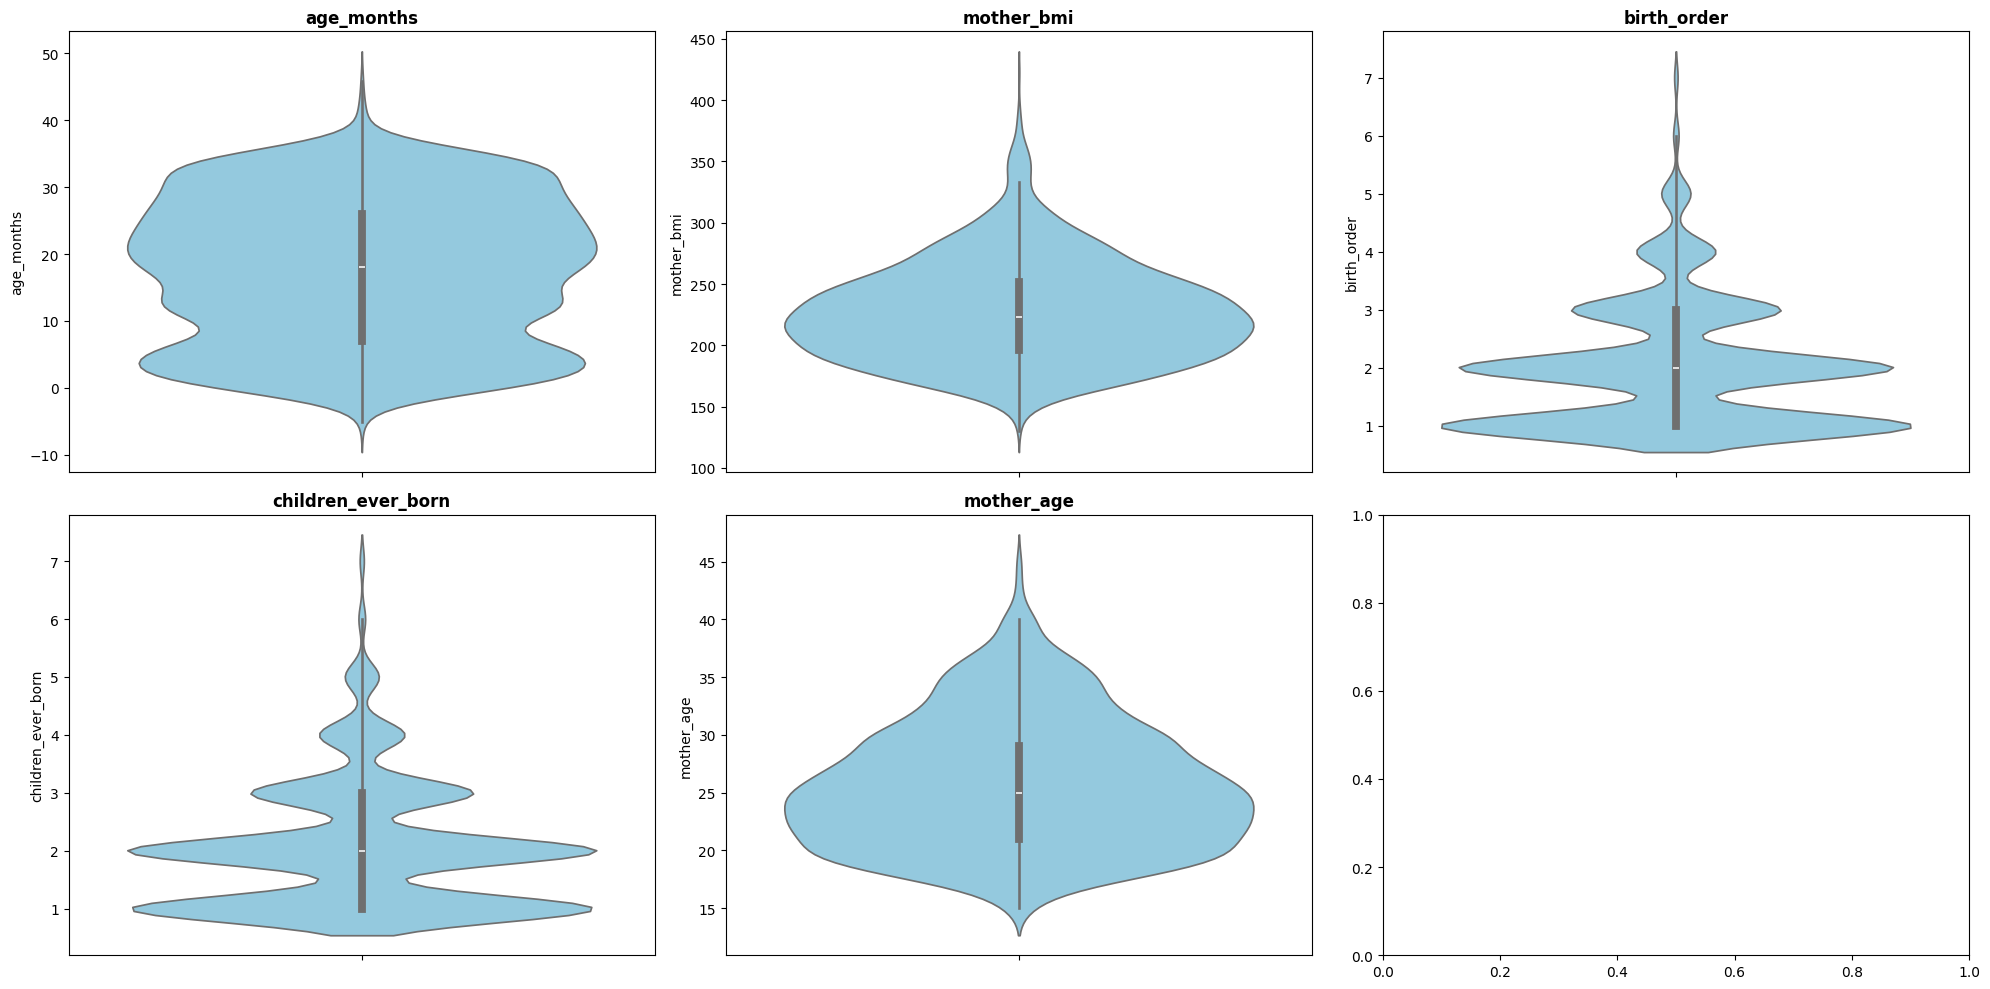

In [47]:
# Select numerical columns
num_cols = ['age_months',  'mother_bmi',   'birth_order',
            'children_ever_born', 'mother_age']

df_num = df[num_cols].dropna()

# Violin plot grid
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    sns.violinplot(y=df_num[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

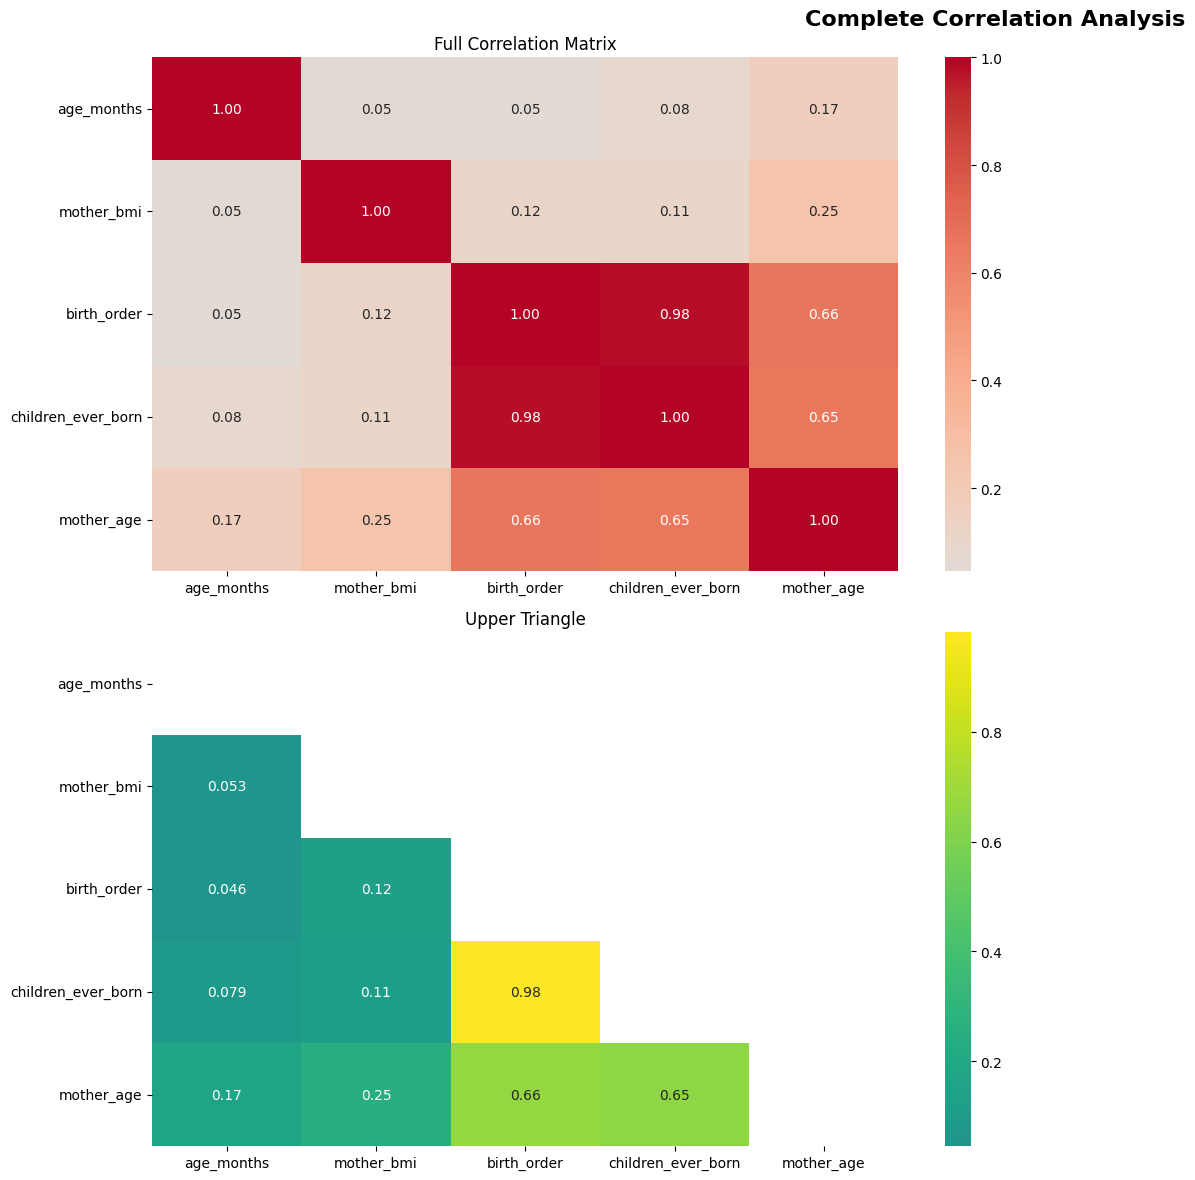

In [48]:
fig = plt.figure(figsize=(20, 12))

# Full matrix
ax1 = plt.subplot(2, 2, 1)
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm', center=0, ax=ax1, fmt='.2f')
ax1.set_title('Full Correlation Matrix')



# Clustered
ax3 = plt.subplot(2, 2, 3)
sns.heatmap(df_num.corr(), mask=np.triu(np.ones_like(df_num.corr())),
            annot=True, cmap='viridis', center=0, ax=ax3)
ax3.set_title('Upper Triangle')



plt.suptitle('Complete Correlation Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [101]:
def fix_categorical_for_plotly(df):
    """Fix all categorical issues for Plotly"""
    df_fixed = df.copy()

    # Convert common categorical numerics
    numeric_cols = ['wt',  'age_months']
    for col in numeric_cols:
        if col in df_fixed.columns:
            df_fixed[col + '_num'] = pd.to_numeric(df_fixed[col], errors='coerce')

    # Convert stunted to int
    if 'stunted' in df_fixed.columns:
        df_fixed['stunted_int'] = df_fixed['stunted'].astype(int)

    return df_fixed

# Apply fix
df_clean = fix_categorical_for_plotly(df)

# Perfect 3D plot
fig = px.scatter_3d(
    df_clean.dropna(subset=['age_months', 'mother_bmi', 'haz', ]),
    x='age_months',
    y='mother_bmi',
    z='haz',
    color='stunted_int',
    size='wt_num',
    title='  3D Plot '
)
fig.show()

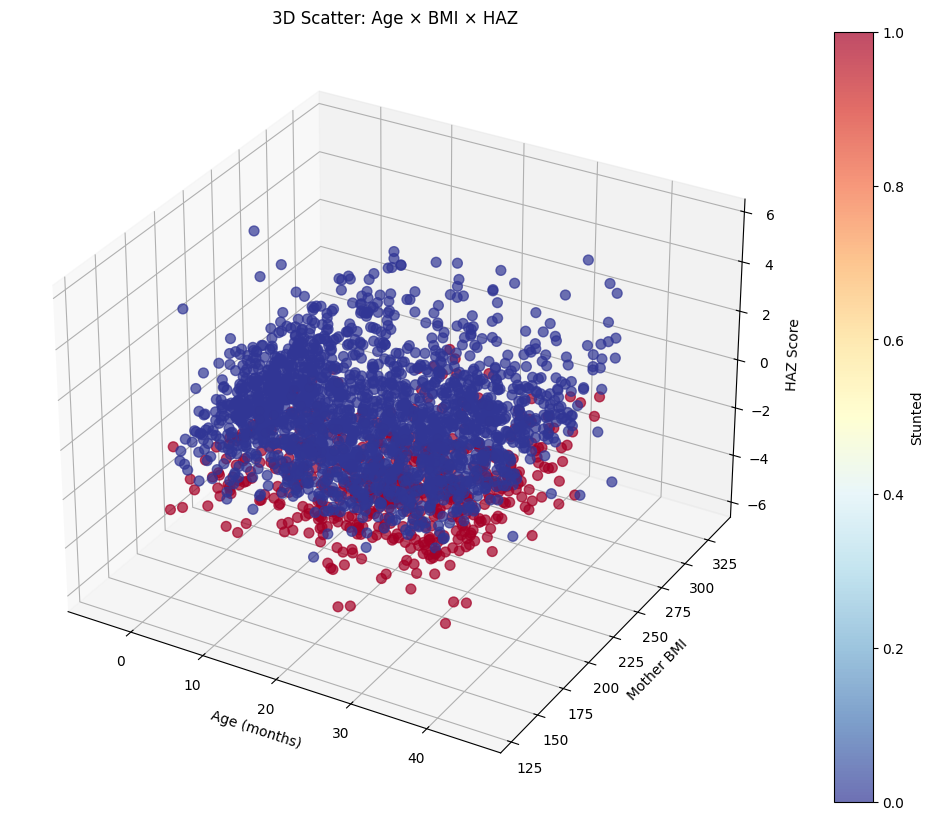

In [102]:
def fix_categorical_for_plotly(df):
    """Fix all categorical issues for Plotly"""
    df_fixed = df.copy()


    # Convert common categorical numerics
    numeric_cols = ['wt', 'sample_weight', 'age_months']
    for col in numeric_cols:
        if col in df_fixed.columns:
            df_fixed[col + '_num'] = pd.to_numeric(df_fixed[col], errors='coerce')

    # Convert stunted to int
    if 'stunted' in df_fixed.columns:
        df_fixed['stunted_int'] = df_fixed['stunted'].astype(int)

    return df_fixed

# Apply fix
df_clean = fix_categorical_for_plotly(df)

# Perfect 3D plot
fig = px.scatter_3d(
    df_clean.dropna(subset=['age_months', 'mother_bmi', 'haz', 'wt_num']),
    x='age_months',
    y='mother_bmi',
    z='haz',
    color='stunted_int',
    size='wt_num',
    title=' Perfect 3D Plot'
)
fig.show()

# Matplotlib 3D
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(df['age_months'], df['mother_bmi'], df['haz'],
                    c=df['stunted'], cmap='RdYlBu_r', s=50, alpha=0.7)
ax.set_xlabel('Age (months)')
ax.set_ylabel('Mother BMI')
ax.set_zlabel('HAZ Score')
plt.colorbar(scatter, label='Stunted')
plt.title('3D Scatter: Age × BMI × HAZ')
plt.show()

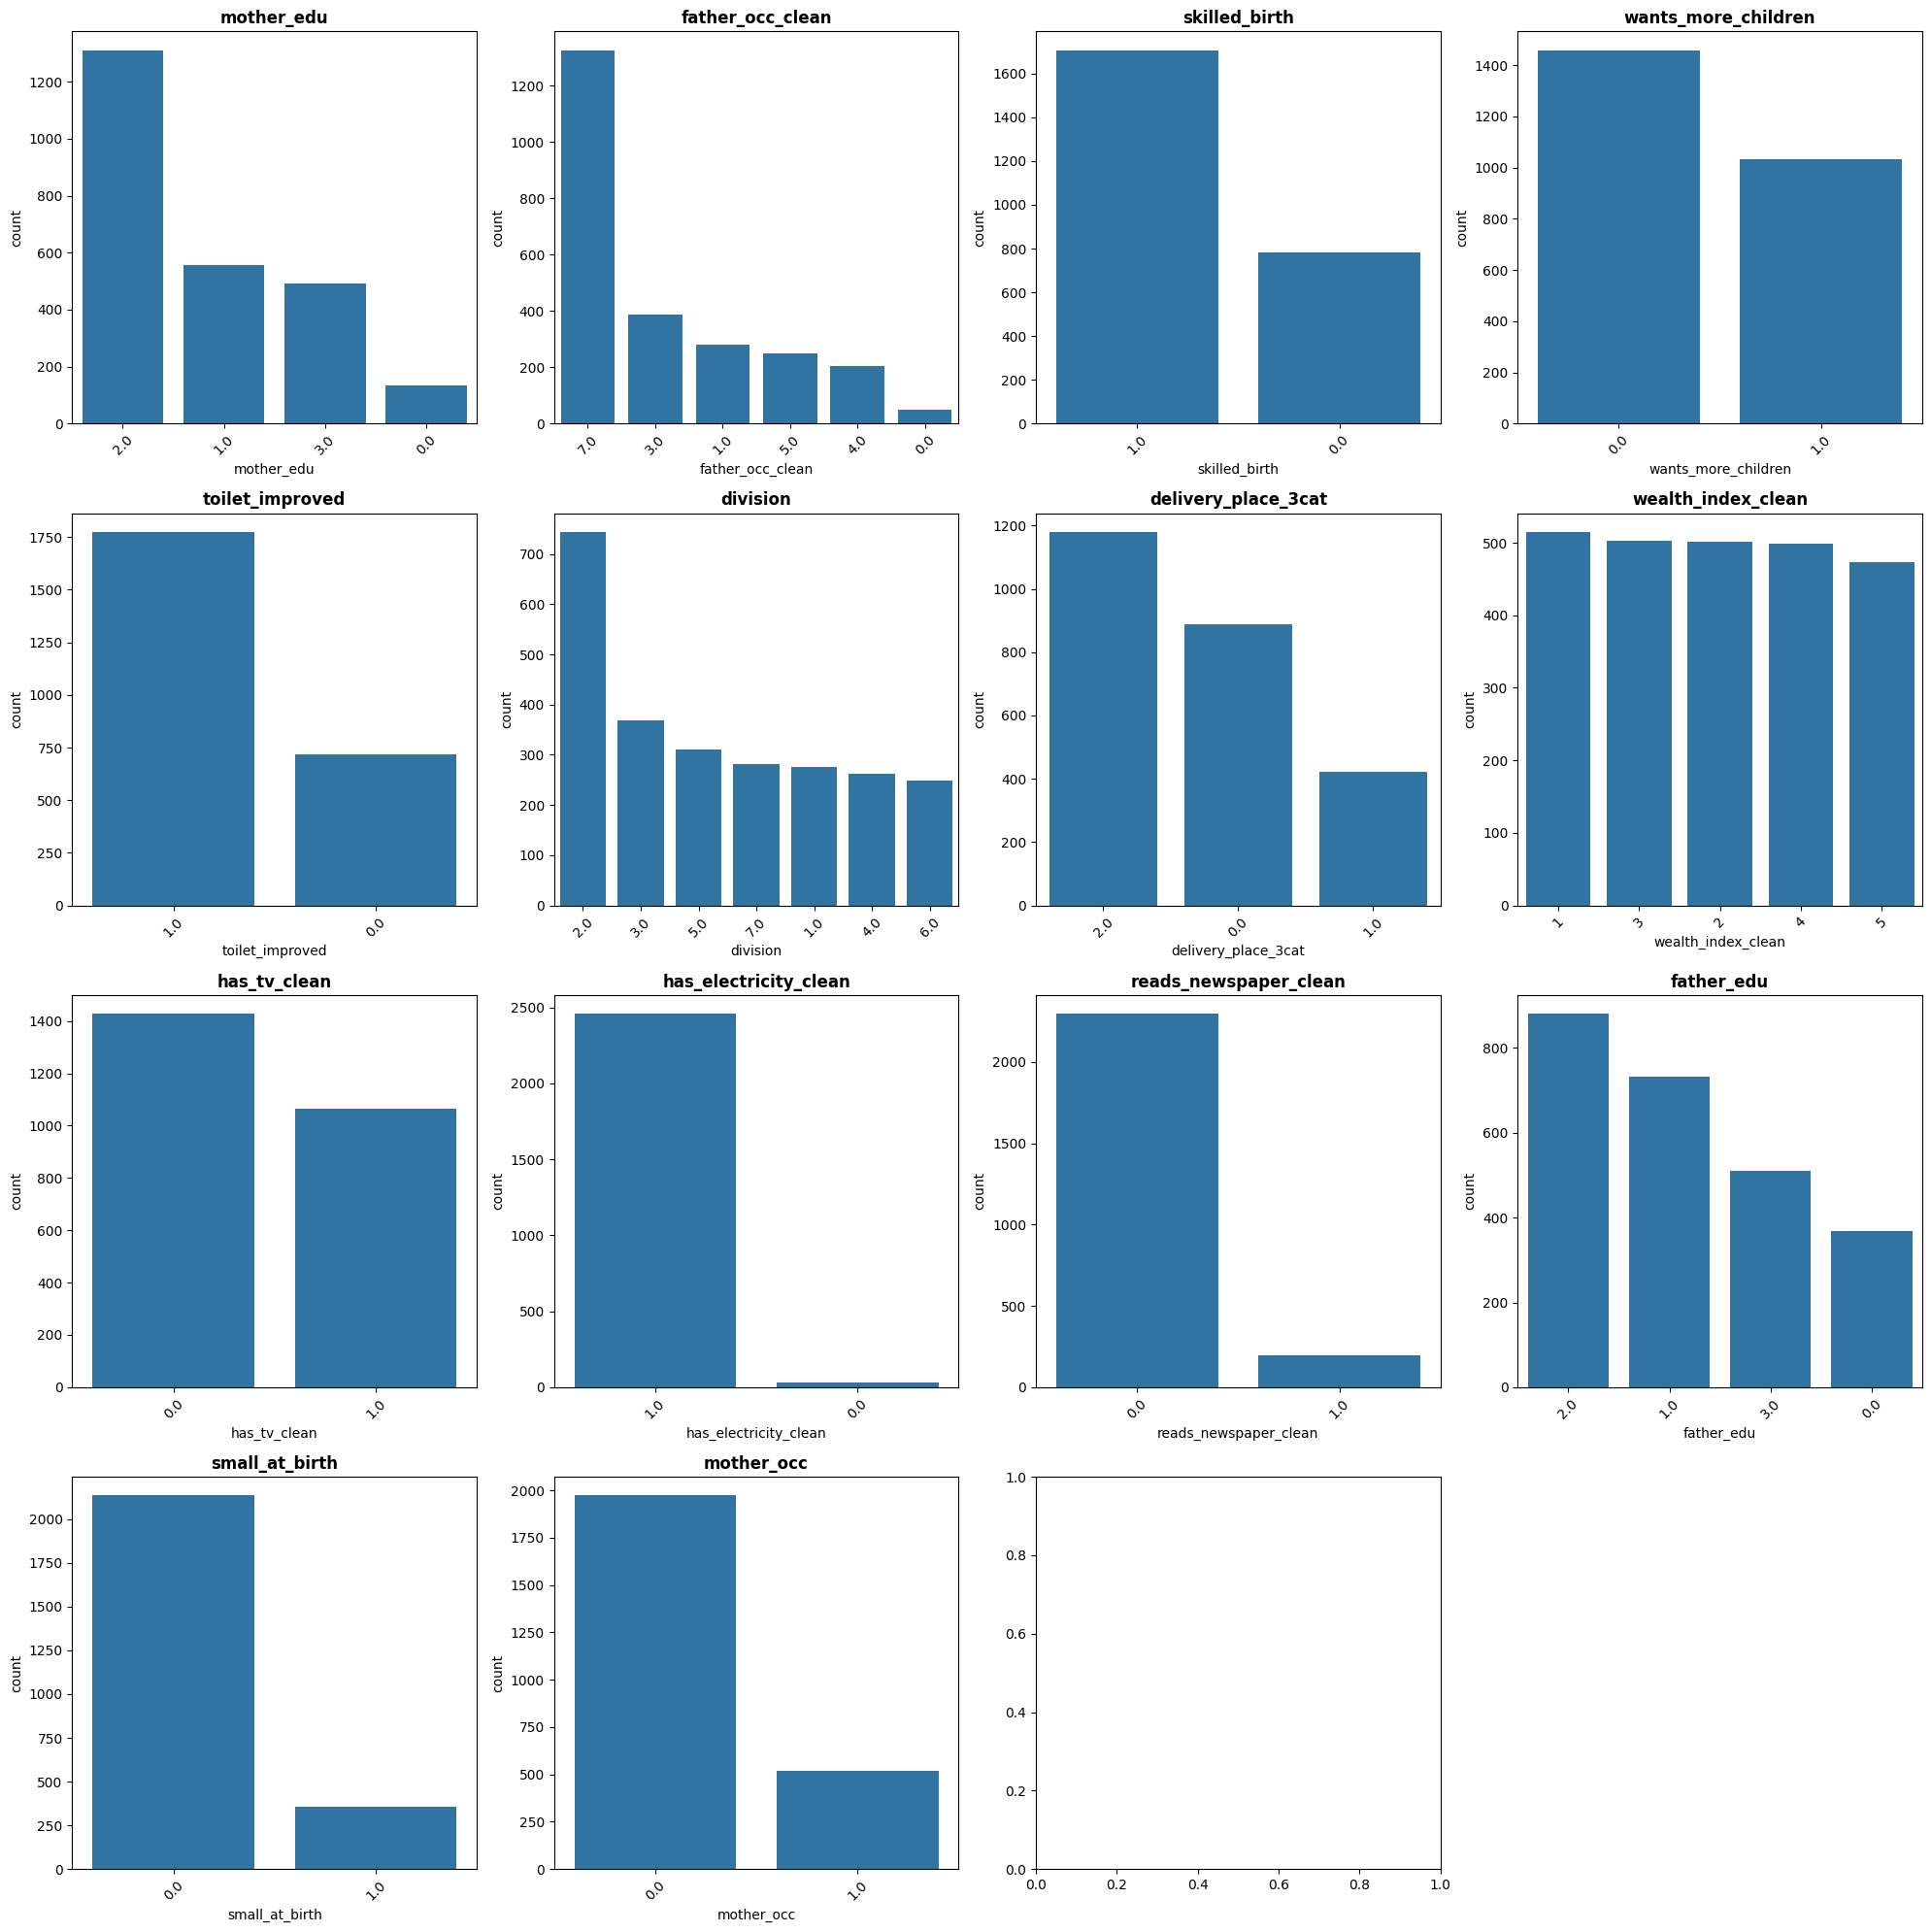

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Your categorical columns
cat_cols = ['mother_edu', 'father_occ_clean', 'skilled_birth', 'wants_more_children',
           'toilet_improved', 'division', 'delivery_place_3cat', 'wealth_index_clean',
           'has_tv_clean', 'has_electricity_clean', 'reads_newspaper_clean',
           'father_edu', 'small_at_birth', 'mother_occ']

# 1. Count plots for all categorical variables
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[idx], order=df[col].value_counts().index)
    axes[idx].set_title(f'{col}', fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45)

# Hide empty subplot
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

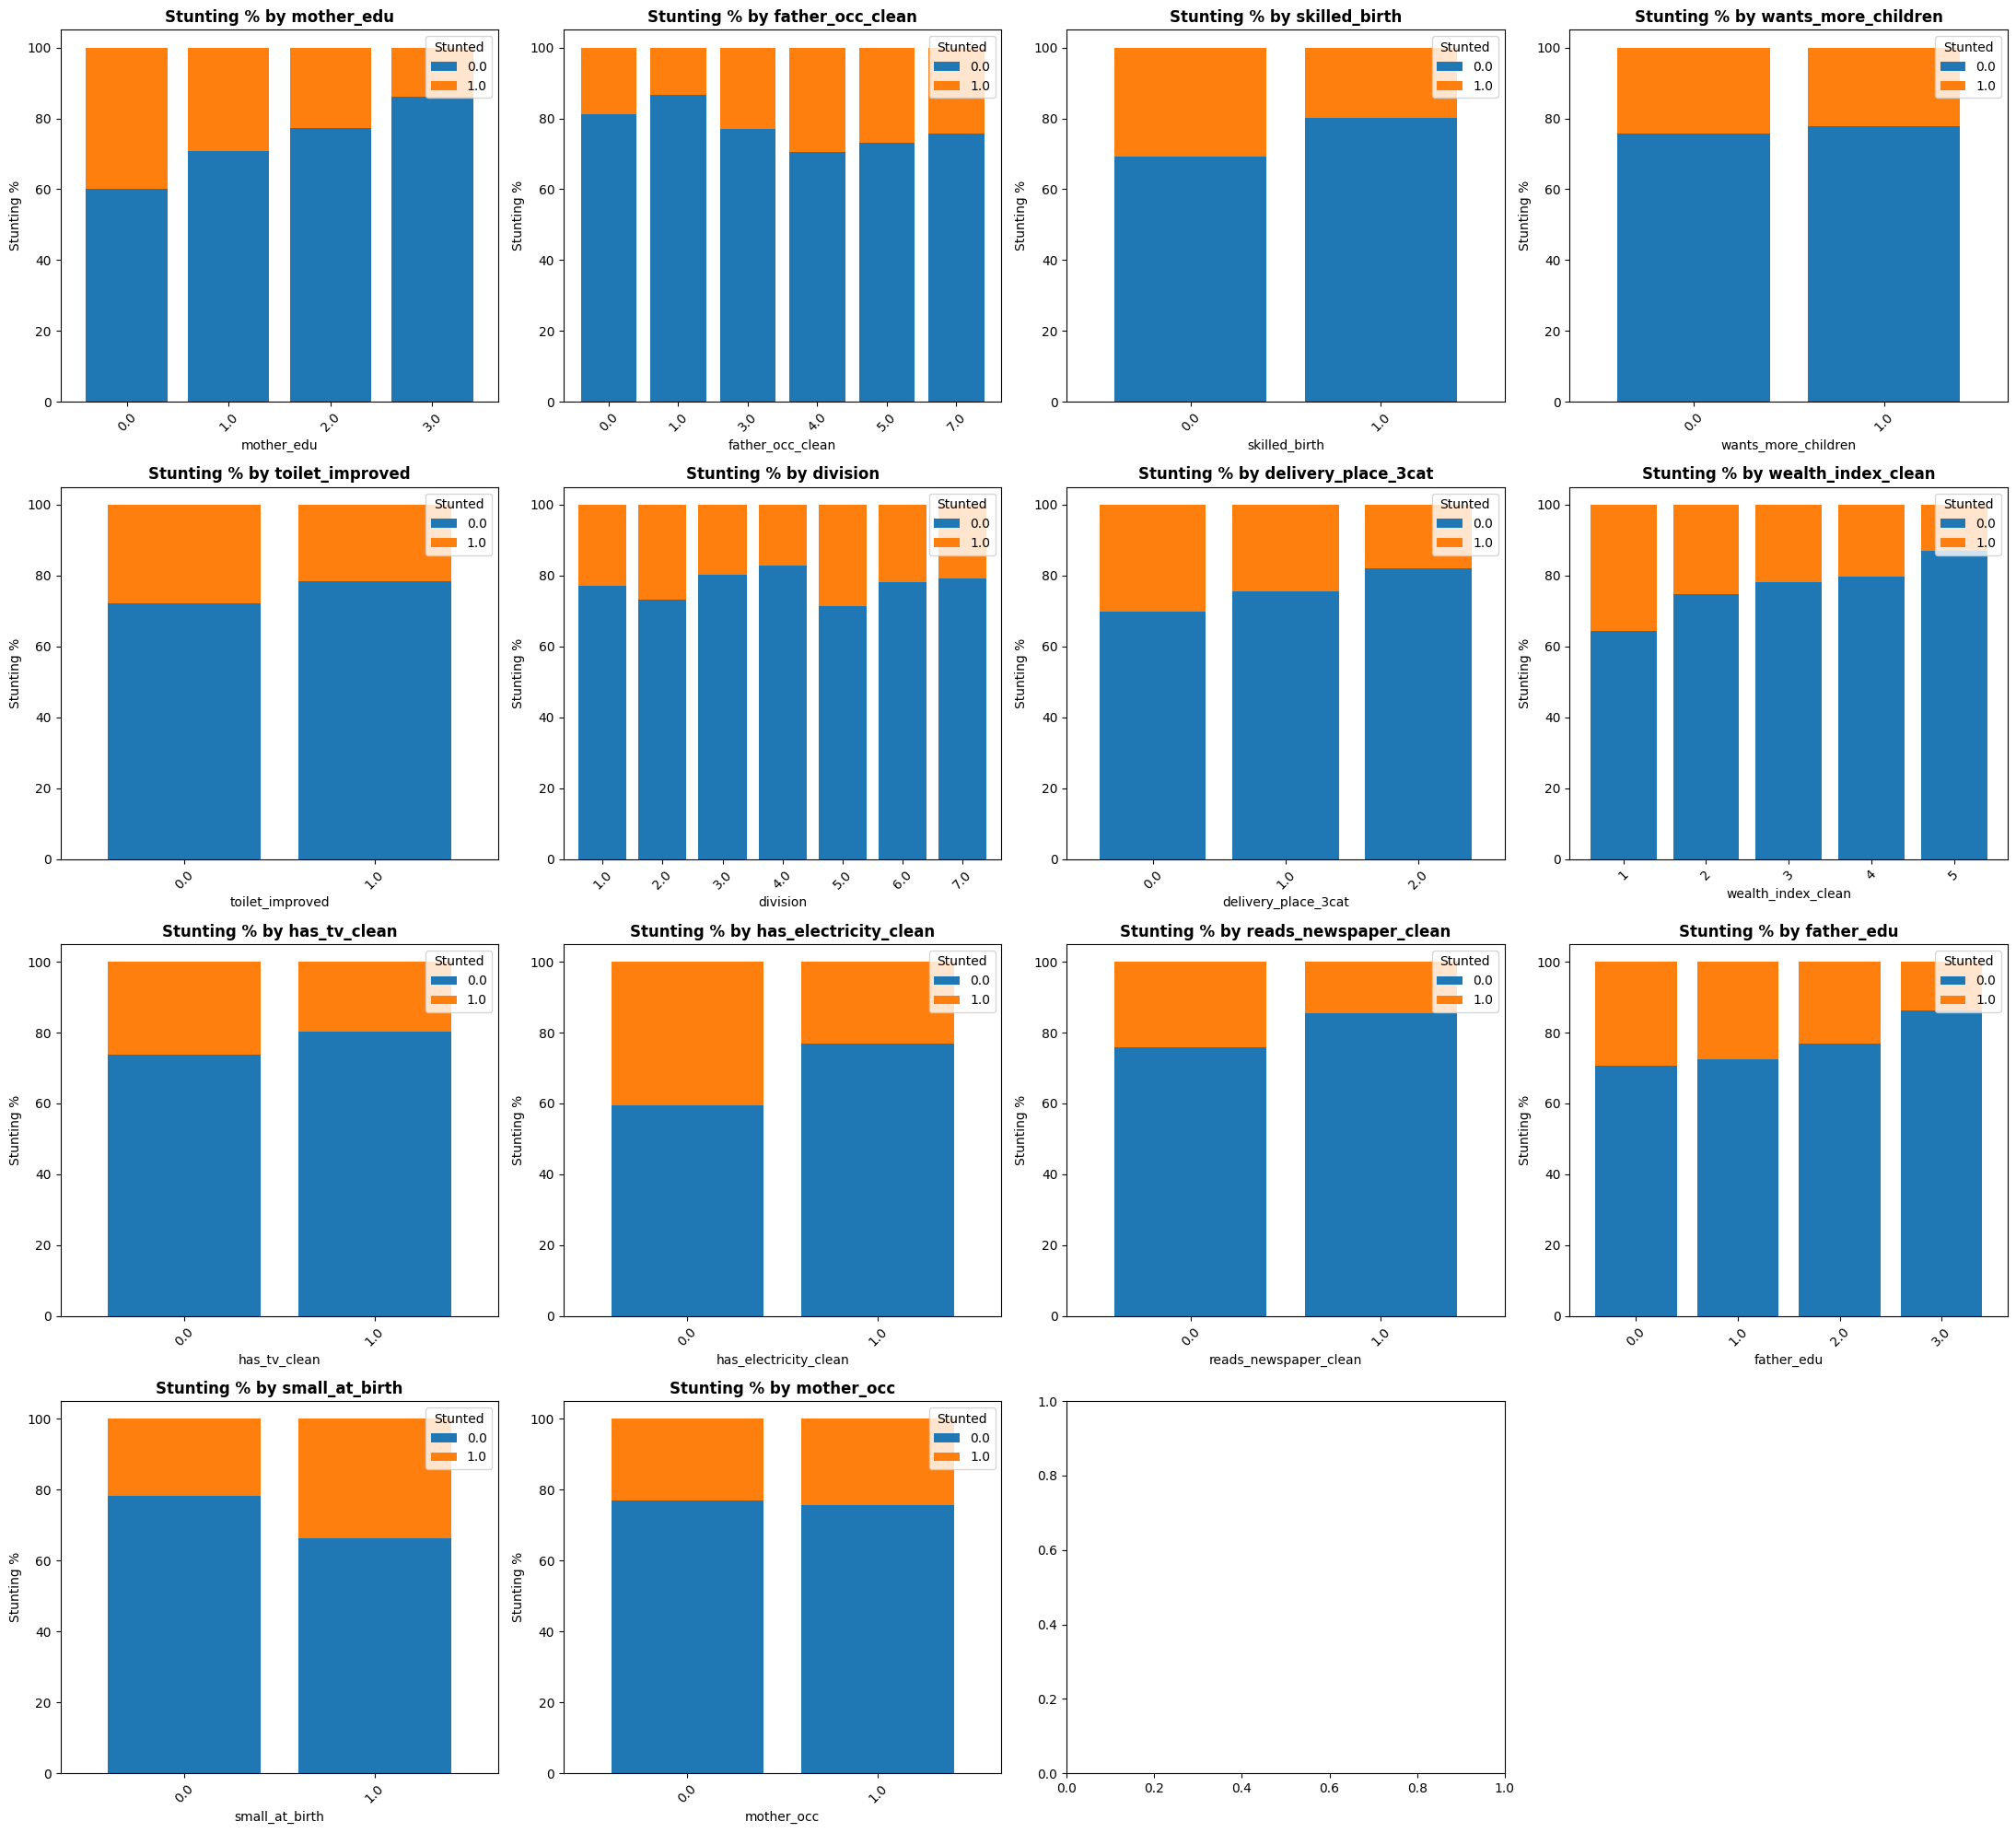

In [55]:
# 2A. Stunting prevalence by each categorical variable
fig, axes = plt.subplots(4, 4, figsize=(22, 20))
axes = axes.ravel()

for idx, col in enumerate(cat_cols):
    if col != 'stunted':  # Skip target
        crosstab = pd.crosstab(df[col], df['stunted'], normalize='index') * 100
        crosstab.plot(kind='bar', stacked=True, ax=axes[idx], width=0.8)
        axes[idx].set_title(f'Stunting % by {col}', fontweight='bold')
        axes[idx].set_ylabel('Stunting %')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].legend(title='Stunted', loc='upper right')

axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

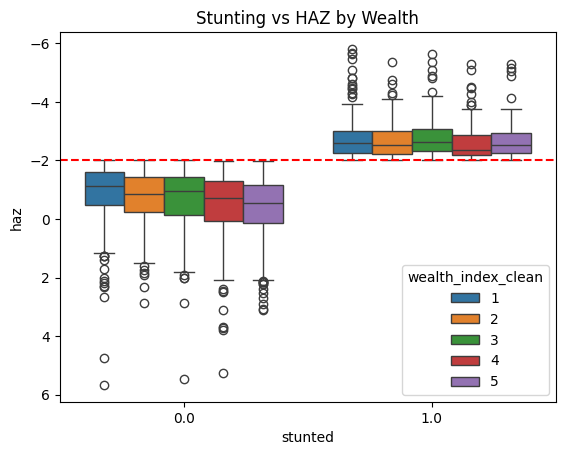

In [58]:
# BEST for stunting analysis
sns.boxplot(data=df, x='stunted', y='haz', hue='wealth_index_clean')
plt.title('Stunting vs HAZ by Wealth')
plt.axhline(y=-2, color='red', linestyle='--')
plt.show()

In [61]:
for col, stats in outlier_results.items():
    print(f"\nColumn: {col}")
    print("Lower bound:", stats["lower_bound"])
    print("Upper bound:", stats["upper_bound"])
    print("Number of outliers:", stats["num_outliers"])



Column: age_months
Lower bound: -21.5
Upper bound: 54.5
Number of outliers: 0

Column: children_ever_born
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 8

Column: mother_age
Lower bound: 9.0
Upper bound: 41.0
Number of outliers: 11

Column: birth_order
Lower bound: -2.0
Upper bound: 6.0
Number of outliers: 7

Column: mother_bmi
Lower bound: 113.47499999999997
Upper bound: 334.87500000000006
Number of outliers: 44
